In [1]:
!git clone https://github.com/michaelhunter12/linear_models.git

Cloning into 'linear_models'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 68 (delta 20), reused 12 (delta 12), pack-reused 38 (from 1)
Receiving objects: 100% (68/68), 3.60 MiB | 8.66 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelBinarizer
import pandas as pd

# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [5]:
Q1 = pd.read_csv('linear_models/data/Q1_clean.csv')
Q1.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [11]:
avg_neighbourhood = Q1.groupby('Neighbourhood ')[['Price', 'Review Scores Rating']].mean()
display(avg_neighbourhood)

,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


Manhattan is the most expensive on average.

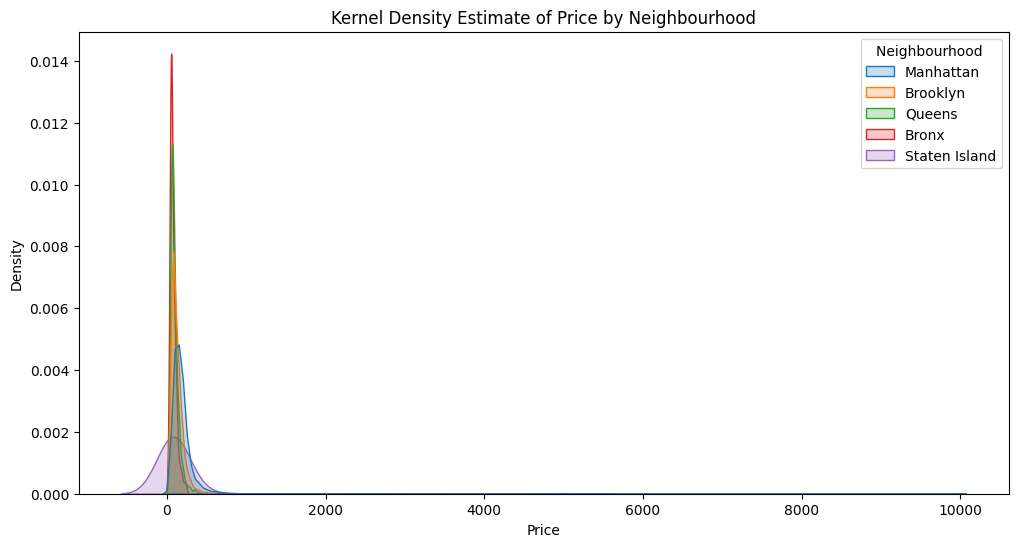

In [12]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=Q1, x='Price', hue='Neighbourhood ', fill=True, common_norm=False)
plt.title('Kernel Density Estimate of Price by Neighbourhood')
plt.xlabel('Price')
plt.ylabel('Density')
plt.show()

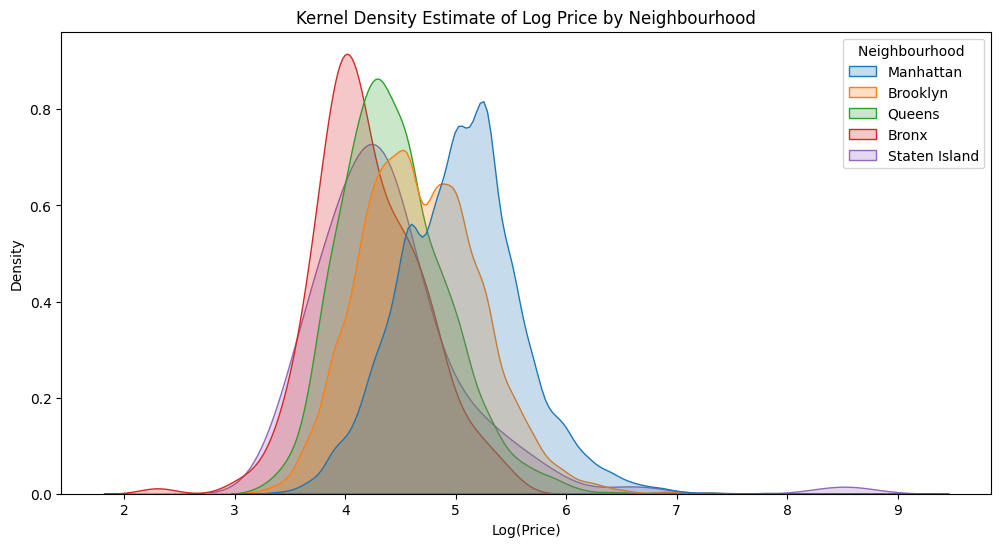

In [13]:
Q1['log_Price'] = np.log(Q1['Price'])

plt.figure(figsize=(12, 6))
sns.kdeplot(data=Q1, x='log_Price', hue='Neighbourhood ', fill=True, common_norm=False)
plt.title('Kernel Density Estimate of Log Price by Neighbourhood')
plt.xlabel('Log(Price)')
plt.ylabel('Density')
plt.show()

In [22]:
X = Q1[['Neighbourhood ']]
y = Q1['Price']

binarizer = LabelBinarizer()
X_encoded = binarizer.fit_transform(X['Neighbourhood '])

feature_names = [f'{c}' for c in binarizer.classes_]
X_encoded_df = pd.DataFrame(X_encoded, columns=feature_names)

model = LinearRegression(fit_intercept=False)
model.fit(X_encoded_df, y)

coefficients_df = pd.DataFrame({'Neighbourhood': feature_names, 'Coefficient/Price': model.coef_})
display(coefficients_df)

,Neighbourhood,Coefficient/Price
0,Bronx,75.276498
1,Brooklyn,127.747378
2,Manhattan,183.664286
3,Queens,96.857233
4,Staten Island,146.166667


The pattern is that the coeffiecient perfectaly matches the average price. For a regresion of a continuous variable on one categorical, the coffiecient/price for the regression are just the mean values for the neighborhood price.

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Prepare data for regression
X = Q1[['Neighbourhood ']]
y = Q1['Price']

# Create one-hot encoded variables with pd.get_dummies()
# drop_first=True avoids the dummy variable trap by dropping one category
# The dropped category becomes the 'reference' category, and its mean price
# is absorbed into the intercept.
X_encoded_with_intercept = pd.get_dummies(X, columns=['Neighbourhood '], drop_first=True, dtype=int)

# Initialize and fit the linear regression model with an intercept
model_with_intercept = LinearRegression(fit_intercept=True)
model_with_intercept.fit(X_encoded_with_intercept, y)

# Display intercept and coefficients
print(f"Intercept: {model_with_intercept.intercept_:.2f}")
coefficients_with_intercept_df = pd.DataFrame({
    'Neighbourhood_Category': X_encoded_with_intercept.columns,
    'Coefficient': model_with_intercept.coef_
})
display(coefficients_with_intercept_df)

### Handling Dummy Variables with an Intercept

When a linear regression model includes an intercept, you must drop one of the one-hot encoded dummy variables for a categorical feature to avoid **multicollinearity** (the 'dummy variable trap'). If you keep all dummy variables plus an intercept, the sum of the dummy variables will always be 1 (representing a constant), which is perfectly correlated with the intercept term. This makes the model unsolvable.

By dropping one category (e.g., 'Bronx' in this case, because `drop_first=True` often drops the alphabetically first category), that category becomes the **reference group**.

### Interpretation of the Intercept

The **intercept** in this model represents the predicted `Price` for the **reference category** (the category whose dummy variable was dropped). In our case, if 'Bronx' was dropped (which `pd.get_dummies(drop_first=True)` would do if it's the first alphabetically), the intercept of **$75.28** represents the average price of properties in **Bronx**.

### Interpretation of the Coefficients

The **coefficients** for the remaining dummy variables represent the **difference** in the predicted `Price` between that specific category and the **reference category**. For example:

*   A coefficient of `52.47` for `Neighbourhood _Brooklyn` means that, on average, properties in Brooklyn are **$52.47 more expensive** than properties in the Bronx.
*   A coefficient of `108.39` for `Neighbourhood _Manhattan` means that, on average, properties in Manhattan are **$108.39 more expensive** than properties in the Bronx.

### Getting Coefficients from Part 2 from These New Coefficients

In Part 2, the coefficients were the *average price* for each neighbourhood. With an intercept, the coefficients are *differences* from the reference category. To get the average price for any given neighbourhood from this new model, you simply add its coefficient to the intercept (which is the average price of the reference category):

*   **Bronx (Reference Category):** Intercept = $75.28 (This is its average price)
*   **Brooklyn:** Intercept + Coefficient (Brooklyn) = $75.28 + $52.47 = $127.75
*   **Manhattan:** Intercept + Coefficient (Manhattan) = $75.28 + $108.39 = $183.67
*   **Queens:** Intercept + Coefficient (Queens) = $75.28 + $21.58 = $96.86
*   **Staten Island:** Intercept + Coefficient (Staten Island) = $75.28 + $70.89 = $146.17

These derived values exactly match the average prices calculated in Part 1 and the coefficients from Part 2, demonstrating the relationship between the two model specifications.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.